In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [8]:
data = load_breast_cancer()

In [10]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [12]:
data['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [14]:
data['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [18]:
x = data.data
y = data.target

In [20]:
x.shape

(569, 30)

In [22]:
y.shape

(569,)

In [28]:
y


In [24]:
pd.DataFrame(data['target']).value_counts()

1    357
0    212
Name: count, dtype: int64

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [28]:
model = LogisticRegression(solver='liblinear')

In [30]:
model

LogisticRegression(solver='liblinear')

In [32]:
model.fit(x_train,y_train)

LogisticRegression(solver='liblinear')

In [34]:
y_test_prediction = model.predict(x_test)


In [36]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1])

In [38]:
y_test_prediction

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1])

In [40]:
score_accuracy = accuracy_score(y_test, y_test_prediction)
print("Accuracy Testing Score: ", score_accuracy)

Accuracy Testing Score:  0.9649122807017544


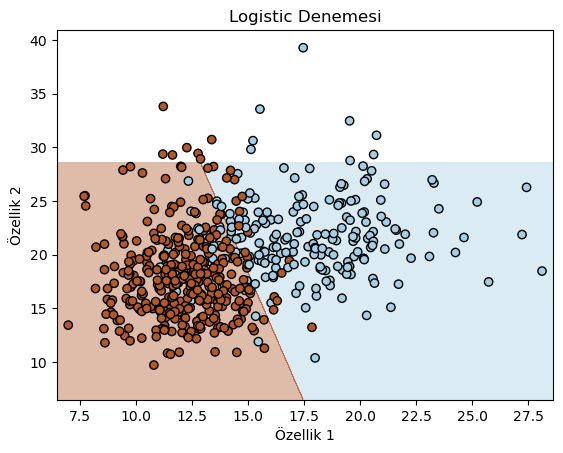

In [62]:
x = data.data [:, [0,1]]
y = data.target 

model = LogisticRegression()

model.fit(x,y)

x_min, x_max = x[:,0].min() - 0.5, x[:,0].max() + 0.5
y_min, y_max = x[:,0].min() - 0.5, x[:,0].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(yy.shape)

plt.contourf(xx,yy,Z, alpha = 0.4, cmap = plt.cm.Paired)
plt.scatter(x[:, 0 ] , x[:, 1], c = y, edgecolors = 'k', cmap = plt.cm.Paired)
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.title('Logistic Denemesi')
plt.show()